In [1]:
#Import des librairies nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

In [2]:
#Chargement des csv

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
#Regarder les premières lignes

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Regarder la structure entière

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
#Voir les valeurs manquantes

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

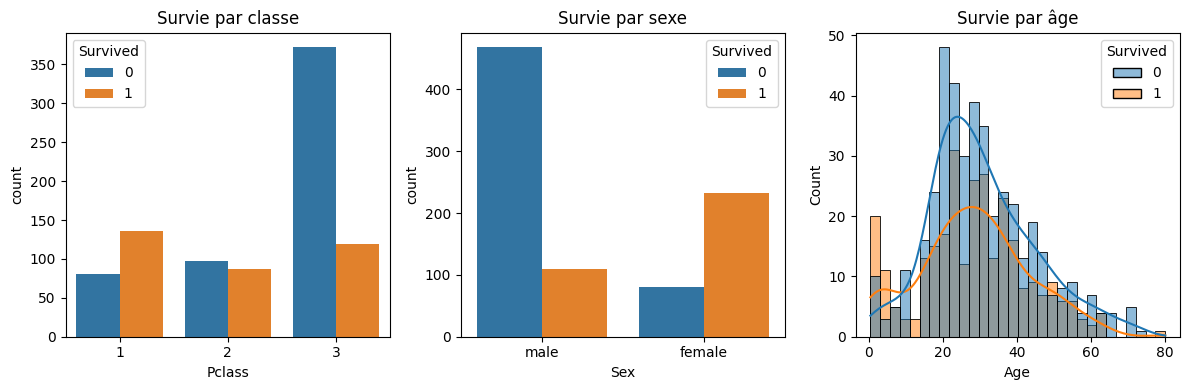

In [6]:
#Visualisation des données pour mieux comprendre

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(data=train, x='Pclass', hue='Survived')
plt.title('Survie par classe')

plt.subplot(1, 3, 2)
sns.countplot(data=train, x='Sex', hue='Survived')
plt.title('Survie par sexe')

plt.subplot(1, 3, 3)
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Survie par âge')

plt.tight_layout()
plt.show()

In [7]:
#Ces graphiques montrent que les femmes et la première classe ont beaucoup plus survécu

In [8]:
#Extraction des titres depuis les noms

train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

train['Title'].value_counts()

<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/96/zh7n1c3j5r3559p0r8yl44jr0000gn/T/ipykernel_2295/3378448826.py:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/var/folders/96/zh7n1c3j5r3559p0r8yl44jr0000gn/T/ipykernel_2295/3378448826.py:4: Sy

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [9]:
#Regroupement des titres rares

train['Title'] = train['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train['Title'] = train['Title'].replace('Mlle', 'Miss')
train['Title'] = train['Title'].replace('Ms', 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')

test['Title'] = test['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
test['Title'] = test['Title'].replace('Mlle', 'Miss')
test['Title'] = test['Title'].replace('Ms', 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')

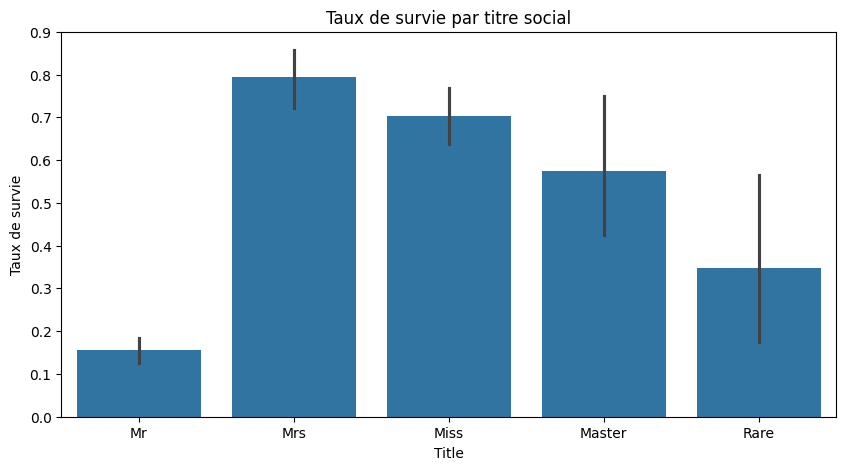

In [10]:
#Visualisation du taux de survie par titre

plt.figure(figsize=(10, 5))
sns.barplot(data=train, x='Title', y='Survived')
plt.title('Taux de survie par titre social')
plt.ylabel('Taux de survie')
plt.show()

In [11]:
#Les Mrs et Miss ont un taux de survie très élevé

In [12]:
#Nettoyage des données

train.drop("Cabin", axis=1, inplace=True)
test.drop("Cabin", axis=1, inplace=True)

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())
test["Fare"] = test["Fare"].fillna(test["Fare"].median())

In [13]:
#Encodage des variables

train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
test["Sex"] = test["Sex"].map({"male": 0, "female": 1})

title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train['Title'] = train['Title'].map(title_mapping)
test['Title'] = test['Title'].map(title_mapping)

train = pd.get_dummies(train, columns=["Embarked"], drop_first=True)
test = pd.get_dummies(test, columns=["Embarked"], drop_first=True)

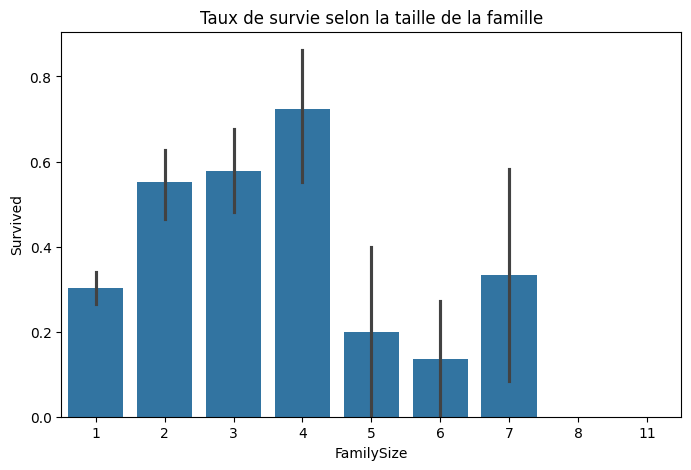

In [14]:
#Création de la variable FamilySize

train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='FamilySize', y='Survived')
plt.title('Taux de survie selon la taille de la famille')
plt.show()

In [15]:
#Les familles de 2 à 4 personnes survivent mieux

In [16]:
#Préparation des données finales

test_ids = test["PassengerId"]

train = train.drop(["Name", "Ticket", "PassengerId"], axis=1)
test = test.drop(["Name", "Ticket", "PassengerId"], axis=1)

X = train.drop("Survived", axis=1)
y = train["Survived"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#Test avec Logistic Regression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_val)
accuracy_lr = accuracy_score(y_val, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7821229050279329


In [18]:
#Test avec Gradient Boosting

model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)
accuracy_gb = accuracy_score(y_val, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.8212290502793296


In [19]:
#Test avec Random Forest

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_val)
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8324022346368715


In [24]:
#Tableau d'importance des variables

pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

,Variable,Importance
5,Fare,0.244597
2,Age,0.212136
6,Title,0.190180
1,Sex,0.132047
0,Pclass,0.076111
9,FamilySize,0.059261
3,SibSp,0.033880
8,Embarked_S,0.022821
4,Parch,0.019600
7,Embarked_Q,0.009367


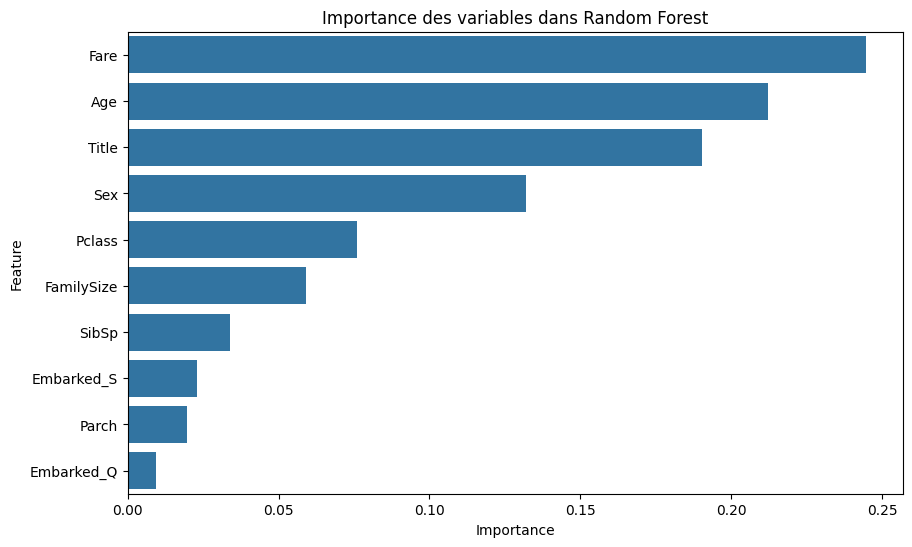

In [20]:
#Visualisation de l'importance des features

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Importance des variables dans Random Forest')
plt.show()

In [21]:
#Entraînement du modèle final sur toutes les données

final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

predictions = final_model.predict(test)

In [22]:
#Création du fichier de soumission pour Kaggle

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)
print("Fichier submission.csv créé avec succès !")
submission.head(10)

Fichier submission.csv créé avec succès !


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


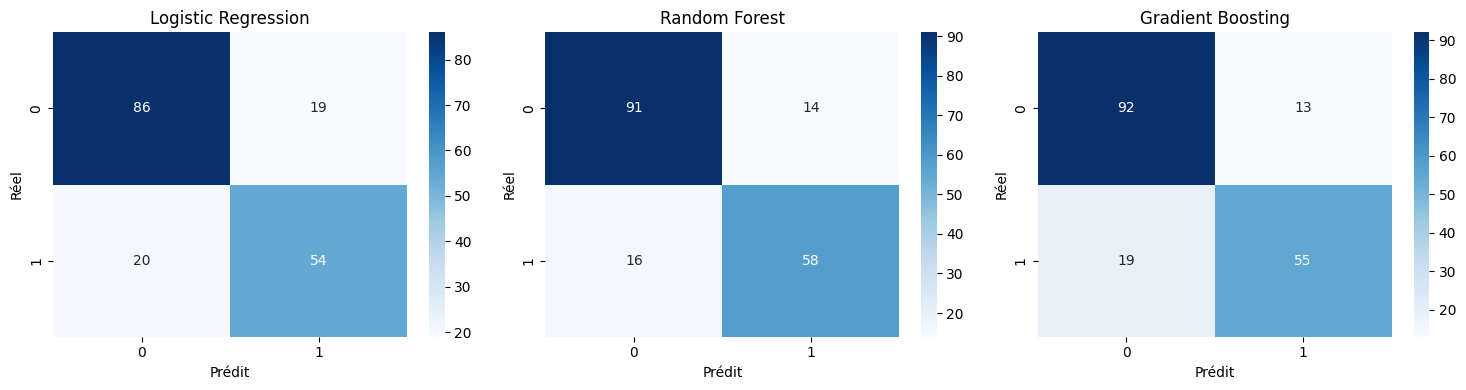

In [23]:
#Matrices de confusion

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

plt.tight_layout()
plt.show()